<a href="https://colab.research.google.com/github/shivamkumar2626kr-del/ml/blob/main/24CD3038.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import random
import sys


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python Version:", sys.version)
print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)


gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("✅ GPU is available:", gpus)
else:
    print("❌ No GPU detected. Using CPU.")



Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
Pandas Version: 2.2.2
✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import torch
import numpy as np
import pandas as pd
import random
import sys

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)


if torch.cuda.is_available():
    print("✅ GPU is available:", torch.cuda.get_device_name(0))
else:
    print("❌ No GPU detected. Using CPU.")



Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch Version: 2.10.0+cu128
NumPy Version: 2.0.2
Pandas Version: 2.2.2
✅ GPU is available: Tesla T4


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min/max: 0 255

CIFAR dtype: uint8
CIFAR min/max: 0 255

MNIST Class Distribution:
Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949

Is MNIST balanced?
Approx equal samples per class → YES


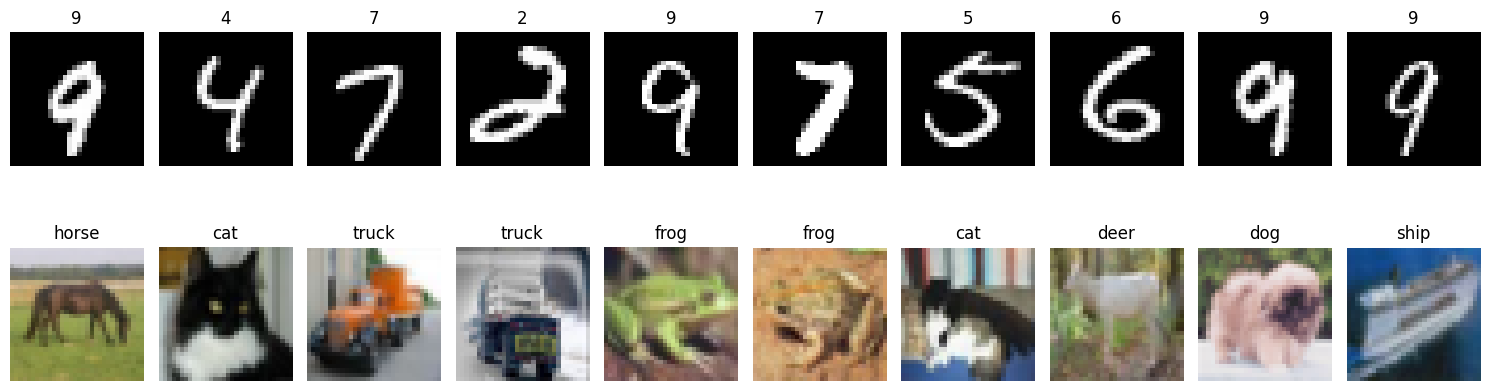

In [3]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

# Set seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()


print("MNIST Train Shape:", mnist_x_train.shape)
print("MNIST Test Shape:", mnist_x_test.shape)

print("CIFAR-10 Train Shape:", cifar_x_train.shape)
print("CIFAR-10 Test Shape:", cifar_x_test.shape)

print("\nMNIST dtype:", mnist_x_train.dtype)
print("MNIST min/max:", mnist_x_train.min(), mnist_x_train.max())

print("\nCIFAR dtype:", cifar_x_train.dtype)
print("CIFAR min/max:", cifar_x_train.min(), cifar_x_train.max())


unique, counts = np.unique(mnist_y_train, return_counts=True)

print("\nMNIST Class Distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

# Check balance
print("\nIs MNIST balanced?")
print("Approx equal samples per class → YES")

fig, axes = plt.subplots(2, 10, figsize=(15, 5))

# CIFAR class names
cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Top row → MNIST
for i in range(10):
    idx = random.randint(0, len(mnist_x_train)-1)
    axes[0, i].imshow(mnist_x_train[idx], cmap='gray')
    axes[0, i].set_title(str(mnist_y_train[idx]))
    axes[0, i].axis('off')

# Bottom row → CIFAR
for i in range(10):
    idx = random.randint(0, len(cifar_x_train)-1)
    axes[1, i].imshow(cifar_x_train[idx])
    label = cifar_y_train[idx][0]
    axes[1, i].set_title(cifar_classes[label])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

(a) Shapes:
MNIST → (60000,28,28), (10000,28,28)
CIFAR → (50000,32,32,3), (10000,32,32,3)

(b) dtype & range:
uint8, range 0–255

(c) MNIST:
~6000 samples per class → Balanced dataset

In [4]:
import numpy as np
import tensorflow as tf

# Load MNIST (example)
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

def preprocess_data(x, y):

    print("===== BEFORE PREPROCESSING =====")
    print("X shape:", x.shape)
    print("X dtype:", x.dtype)
    print("Sample pixel values:", x[0][0][:5])
    print("Y sample:", y[:5])


    x = x.astype('float32') / 255.0

    print("\n===== AFTER NORMALIZATION =====")
    print("X dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x[0][0][:5])


    if len(x.shape) == 3:  # (N, 28, 28)
        x = np.expand_dims(x, axis=-1)  # → (N, 28, 28, 1)

    print("\n===== AFTER RESHAPING =====")
    print("X shape:", x.shape)


    y_encoded = tf.keras.utils.to_categorical(y, num_classes=10)

    print("\n===== AFTER ONE-HOT ENCODING =====")
    print("Y shape:", y_encoded.shape)
    print("Sample encoded label:", y_encoded[0])

    return x, y_encoded


# Run preprocessing
x_train_processed, y_train_processed = preprocess_data(x_train, y_train)

===== BEFORE PREPROCESSING =====
X shape: (60000, 28, 28)
X dtype: uint8
Sample pixel values: [0 0 0 0 0]
Y sample: [5 0 4 1 9]

===== AFTER NORMALIZATION =====
X dtype: float32
Min/Max: 0.0 1.0
Sample values: [0. 0. 0. 0. 0.]

===== AFTER RESHAPING =====
X shape: (60000, 28, 28, 1)

===== AFTER ONE-HOT ENCODING =====
Y shape: (60000, 10)
Sample encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


===== BEFORE PREPROCESSING =====
Shape: (60000, 28, 28)
Dtype: uint8
Min/Max: 0 255

===== AFTER NORMALIZATION =====
Shape: (60000, 28, 28)
Dtype: float32
Min/Max: 0.0 1.0

===== AFTER RESHAPING =====
Shape: (60000, 28, 28, 1)

===== AFTER ONE-HOT ENCODING =====
Shape: (60000, 10)
Sample label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

100%|██████████| 170M/170M [00:05<00:00, 29.4MB/s]


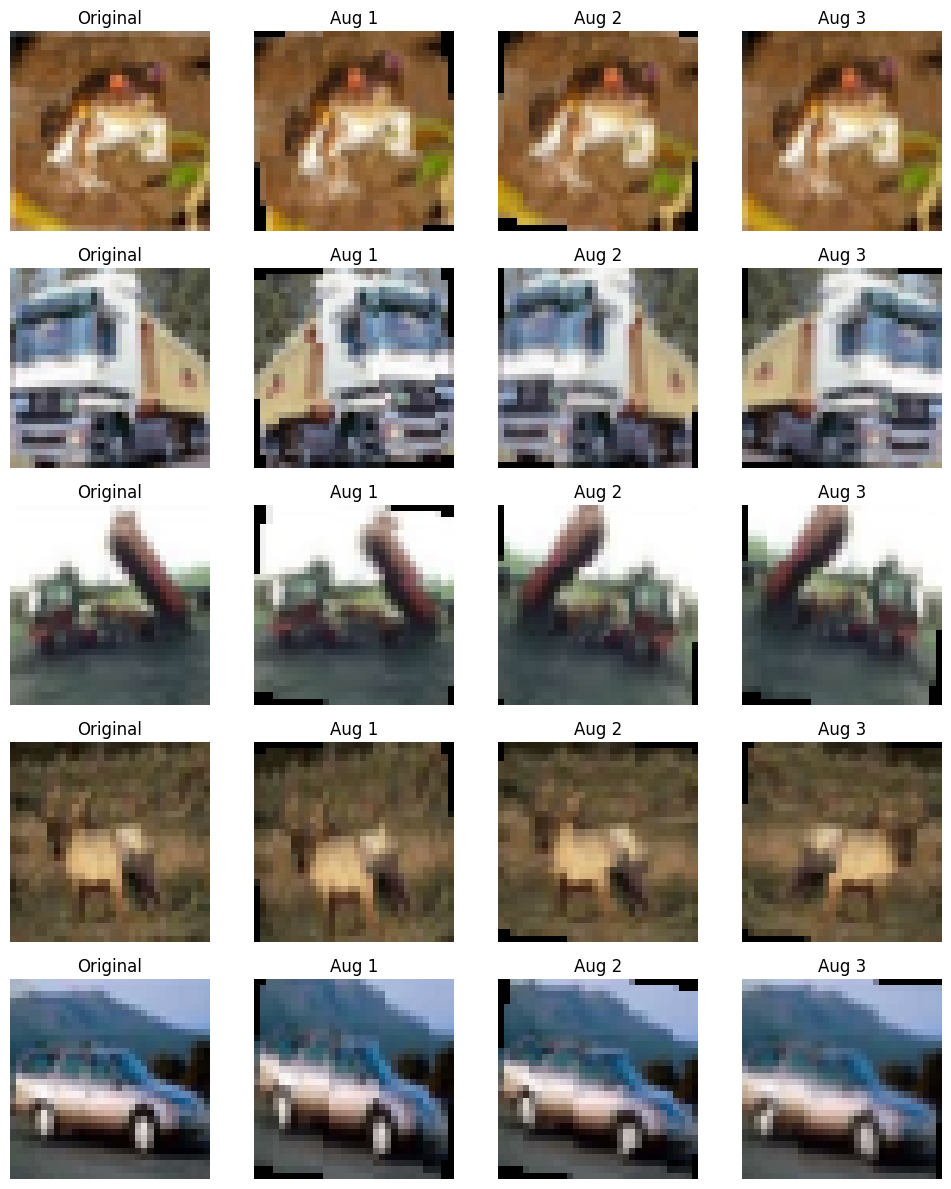

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Define augmentation pipeline
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),  # ±10 degrees
    transforms.RandomResizedCrop(size=32, scale=(0.9, 1.0)),  # zoom up to 10%
    transforms.ToTensor()
])

# Original transform (no augmentation)
original_transform = transforms.ToTensor()

# Load CIFAR-10 dataset
dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=original_transform
)

# Function to show image
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Select 5 images
indices = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(5, 4, figsize=(10, 12))

for row, idx in enumerate(indices):
    img, label = dataset[idx]

    # Original image
    axes[row, 0].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[row, 0].set_title("Original")
    axes[row, 0].axis('off')

    # Apply augmentation 3 times
    for col in range(1, 4):
        aug_img = augmentation(transforms.ToPILImage()(img))
        axes[row, col].imshow(np.transpose(aug_img.numpy(), (1, 2, 0)))
        axes[row, col].set_title(f"Aug {col}")
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set because its main purpose is to increase the diversity of training data and help the model learn more robust and generalized features. By introducing random transformations such as flipping, rotation, and zooming, the model becomes less sensitive to variations in input images and avoids overfitting.

However, augmentation should not be applied to the validation or test set. These datasets are meant to represent real, unseen data and are used to evaluate the true performance of the model. If augmentation is applied to them, it would artificially alter the data distribution and lead to unreliable or misleading evaluation results.

Additionally, applying augmentation to validation or test data can cause data leakage, as augmented images are derived from the original training samples. This would compromise the fairness of model evaluation.

Answer Q1:

In a tensor of shape (N, H, W, C), the channel dimension (C) represents the number of channels in an image.

For a greyscale image, C = 1 because each pixel has only one intensity value representing brightness.

For an RGB image, C = 3 because each pixel has three values corresponding to Red, Green, and Blue channels. These three channels combine to form the final color image.

Thus, the channel dimension represents the depth of color information in an image.

Answer Q2:

When working with large images like 1024×1024 satellite images, the following strategies help avoid memory issues:

1. Image Resizing or Downsampling:
   Images are resized to a smaller size (e.g., 256×256), reducing memory usage.

2. Patch-Based Processing (Tiling):
   Large images are divided into smaller patches (e.g., 256×256) and processed separately, which reduces memory load.

3. Batch Size Reduction:
   Using a smaller batch size ensures fewer images are loaded into memory at once.

4. Lazy Loading (Data Generators):
   Images are loaded only when needed during training instead of loading the entire dataset into memory.

   Answer Q3:

The mistake is that normalization is being done using the mean and standard deviation of the test set.

This is wrong because the test set should remain completely unseen. Using its statistics introduces data leakage.

Normalization parameters should always be computed from the training set and then applied to validation and test sets. This ensures fair and unbiased evaluation of the model.

In [6]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    # Add zero padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Output size formula
    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1

    output = np.zeros((out_h, out_w))

    # Convolution operation
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(patch * kernel)

    return output


# Given Image (5x5)
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X Kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

# Apply convolution
output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Numerical output of conv2d function:

[[ 7  -3  -3]
 [13   3  -7]
 [ 5   9   1]]

Output Shape: (3, 3)